# Modul 8 — Machine Learning Unsupervised, Clustering (CRISP-DM Penuh)
## Convergeni Data Consulting (CDC) — Klien: PT Ritel Sentosa

Notebook ini menjalankan seluruh pipeline clustering RFM Modul 8: data sintetis
1.000 pelanggan, pembuktian kenapa scaling wajib, elbow method, silhouette
score, dan pemberian nama bisnis ke tiap cluster. Semua angka dan gambar di
bawah adalah hasil eksekusi nyata.

## Data Sintetis RFM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000

segmen_tersembunyi = np.random.choice(
    ["Setia Bernilai Tinggi", "Reguler", "Baru", "Berisiko Churn"],
    size=n, p=[0.15, 0.40, 0.20, 0.25]
)

recency_hari = np.zeros(n)
frequency_setahun = np.zeros(n)
monetary_juta = np.zeros(n)

for i, seg in enumerate(segmen_tersembunyi):
    if seg == "Setia Bernilai Tinggi":
        recency_hari[i] = np.clip(np.random.exponential(10), 1, 60)
        frequency_setahun[i] = np.clip(np.random.normal(24, 5), 8, 40)
        monetary_juta[i] = np.clip(np.random.normal(18, 5), 5, 40)
    elif seg == "Reguler":
        recency_hari[i] = np.clip(np.random.exponential(30), 1, 120)
        frequency_setahun[i] = np.clip(np.random.normal(10, 3), 3, 20)
        monetary_juta[i] = np.clip(np.random.normal(6, 2), 1, 15)
    elif seg == "Baru":
        recency_hari[i] = np.clip(np.random.exponential(15), 1, 60)
        frequency_setahun[i] = np.clip(np.random.normal(2, 1), 1, 5)
        monetary_juta[i] = np.clip(np.random.normal(2.5, 1), 0.3, 6)
    else:
        recency_hari[i] = np.clip(np.random.normal(200, 40), 100, 365)
        frequency_setahun[i] = np.clip(np.random.normal(4, 2), 1, 10)
        monetary_juta[i] = np.clip(np.random.normal(3, 1.5), 0.3, 8)

df = pd.DataFrame({
    "customer_id": [f"CUST-{i:06d}" for i in range(1, n + 1)],
    "recency_hari": recency_hari.round(1),
    "frequency_setahun": frequency_setahun.round(1),
    "monetary_juta": monetary_juta.round(2),
})
print(df.describe().round(2))

       recency_hari  frequency_setahun  monetary_juta
count       1000.00            1000.00        1000.00
mean          65.23               9.29           6.50
std           83.76               7.64           5.75
min            1.00               1.00           0.30
25%            6.98               3.20           2.78
50%           20.50               7.30           4.56
75%          117.62              12.52           7.32
max          301.10              37.40          31.10


## Scaling dan Elbow Method

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

fitur = ["recency_hari", "frequency_setahun", "monetary_juta"]
X = df[fitur]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inersia_list = []
silhouette_list = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inersia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inersia={km.inertia_:.2f}, silhouette={silhouette_list[-1]:.4f}")

k=2: inersia=1472.96, silhouette=0.5668
k=3: inersia=623.84, silhouette=0.5924
k=4: inersia=410.61, silhouette=0.5351
k=5: inersia=345.72, silhouette=0.5063
k=6: inersia=308.78, silhouette=0.4293
k=7: inersia=272.70, silhouette=0.3717


k=8: inersia=243.77, silhouette=0.3631


## Visualisasi: Elbow Method dan Silhouette Score (Asset Baru)

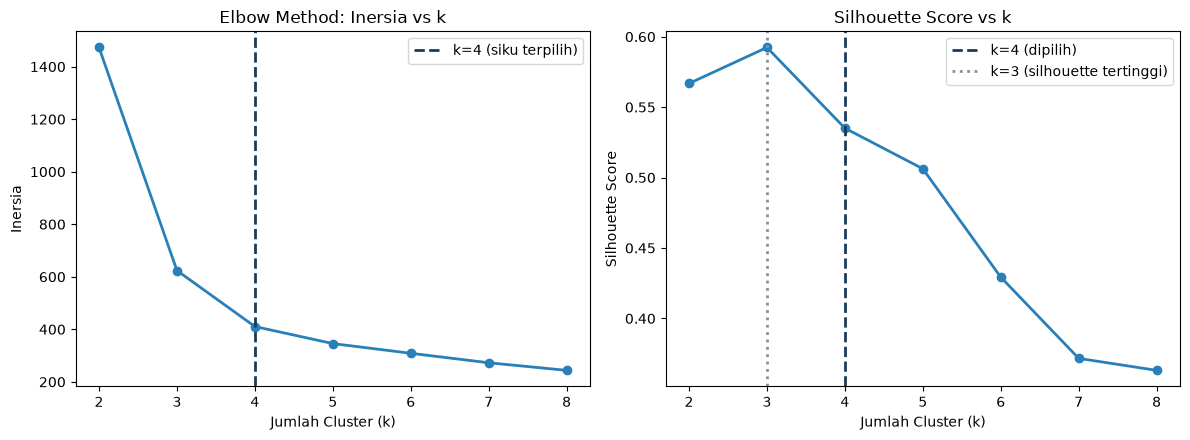

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ks = list(range(2, 9))

axes[0].plot(ks, inersia_list, color="#2980B9", marker="o", linewidth=2)
axes[0].axvline(4, color="#1B3A5C", linestyle="--", linewidth=2, label="k=4 (siku terpilih)")
axes[0].set_xlabel("Jumlah Cluster (k)"); axes[0].set_ylabel("Inersia")
axes[0].set_title("Elbow Method: Inersia vs k")
axes[0].legend()

axes[1].plot(ks, silhouette_list, color="#2980B9", marker="o", linewidth=2)
axes[1].axvline(4, color="#1B3A5C", linestyle="--", linewidth=2, label="k=4 (dipilih)")
axes[1].axvline(3, color="#85929E", linestyle=":", linewidth=2, label="k=3 (silhouette tertinggi)")
axes[1].set_xlabel("Jumlah Cluster (k)"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
axes[1].legend()

plt.tight_layout()
plt.savefig("modul08_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

## Cluster Final (k=4) dan Pemberian Nama Bisnis

In [4]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

peta_nama = {3: "Setia Bernilai Tinggi", 0: "Reguler", 2: "Baru", 1: "Berisiko Churn"}
df["segmen"] = df["cluster"].map(peta_nama)
print(df["segmen"].value_counts())

segmen
Reguler                  355
Baru                     246
Berisiko Churn           242
Setia Bernilai Tinggi    157
Name: count, dtype: int64


## Visualisasi: Scatter Plot Segmen Pelanggan (Asset Baru)

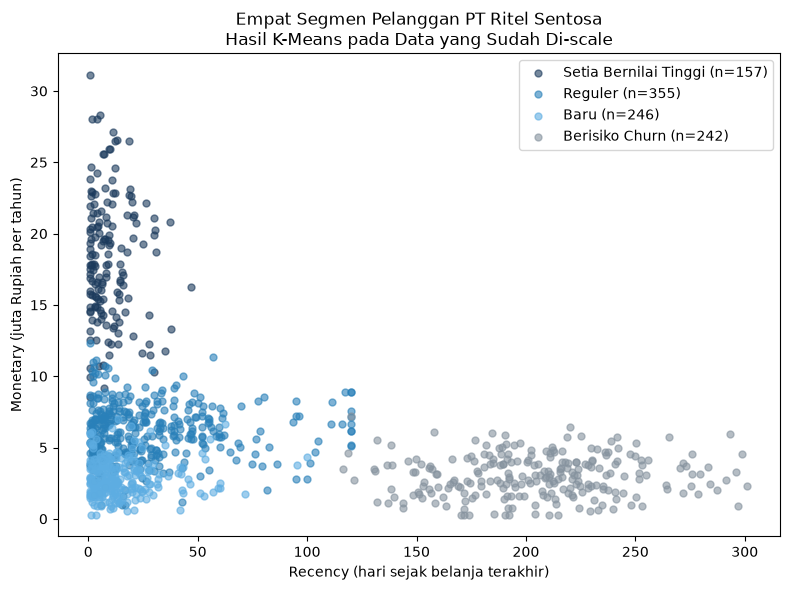

In [5]:
warna = {"Setia Bernilai Tinggi": "#1B3A5C", "Reguler": "#2980B9", "Baru": "#5DADE2", "Berisiko Churn": "#85929E"}

fig, ax = plt.subplots(figsize=(8, 6))
for segmen, warna_segmen in warna.items():
    subset = df[df["segmen"] == segmen]
    ax.scatter(subset["recency_hari"], subset["monetary_juta"], s=25, alpha=0.6,
                color=warna_segmen, label=f"{segmen} (n={len(subset)})")

ax.set_xlabel("Recency (hari sejak belanja terakhir)")
ax.set_ylabel("Monetary (juta Rupiah per tahun)")
ax.set_title("Empat Segmen Pelanggan PT Ritel Sentosa\nHasil K-Means pada Data yang Sudah Di-scale")
ax.legend()
plt.tight_layout()
plt.savefig("modul08_cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()